# Ticket: Feature Engineering sau Time-Series Split
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

## 1. TỔNG QUAN VÀ NGUYÊN TẮC

Notebook này **phải chạy SAU** Notebook 02 (split). Nó đọc các file split trong `data/model/v3`
và ghi ra file đặc trưng trong `data/model/v3/features`.

### Nguyên tắc chống rò rỉ

Mọi đặc trưng suy ra từ target chỉ dùng mốc thời gian **trước** dòng đang tính:

```
lag_k          = target.shift(k)
rolling_window = target.shift(1).rolling(window)
```

Tập validation và test **được phép nhìn ngược** về các split trước đó để lấy lịch sử,
nhưng **không được nhìn** target hiện tại/tương lai của chính nó:

- Đặc trưng của `fold_val` xây từ `fold_train + fold_val`, sau đó **chỉ xuất phần `fold_val`**
- Đặc trưng của `test` xây từ `development + test`, sau đó **chỉ xuất phần `test`**

Đây là khuôn mẫu dự báo thực tế:

> split trước → feature engineering với backward context → train/đánh giá

### Điểm quan trọng: có làm FE cho cả 5 fold

Notebook 02 xuất 10 file fold **trước** khi có đặc trưng. Notebook này xử lý cả 10 file đó
với backward context riêng cho từng fold, để bước tune cross-validation dùng được.


> ### ⚠️ Lưu ý về RAM trước khi chạy

> Notebook này nặng hơn hẳn các bước trước. Tổng khối lượng xử lý khoảng **15 triệu lượt dòng**:
> `development` (2,27tr) + `test` kèm context (2,78tr) + `train` (1,79tr) + `val` kèm context (2,27tr)
> + 5 fold (≈6,8tr).
> 
> Riêng `add_lag_rolling_features` chạy **6 lần `groupby.apply`** (3 lag + 3 rolling window)
> trên từng tập — đây là chỗ tốn RAM và thời gian nhất.
> 
> **Trước khi chạy:** đóng kernel của các notebook khác trong VSCode. Mỗi kernel giữ vài GB
> và không tự nhả sau khi chạy xong — đó chính là nguyên nhân tràn swap 20 GB lần trước.
> 
> Notebook đã ghi file và `gc.collect()` ngay sau mỗi tập để không giữ nhiều DataFrame lớn cùng lúc.


## 2. Import thư viện và khai báo tham số


In [2]:
import gc
import json
import os

import numpy as np
import pandas as pd

# ── Thư mục (đường dẫn tương đối) ──
SPLIT_DIR = '../../data/model/v3/02_split'
OUTPUT_DIR = '../../data/model/v3/03_features'

# ── Tham số đặc trưng ──
VERSION = 'v3'
EXPECTED_FREQ_MINUTES = 15
LAGS = (1, 4, 96)                    # 15 phút, 1 giờ, 24 giờ
ROLLING_WINDOWS = (4, 12, 96)        # 1 giờ, 3 giờ, 24 giờ

CATEGORICAL_COLS = (
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description',
)

# ── Tên cột ──
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# ── Bản đồ mùa Nam bán cầu ──
SOUTHERN_SEASON_MAP = {
    12: 'summer', 1: 'summer', 2: 'summer',
    3: 'autumn', 4: 'autumn', 5: 'autumn',
    6: 'winter', 7: 'winter', 8: 'winter',
    9: 'spring', 10: 'spring', 11: 'spring',
}
SEASON_CODE_MAP = {'summer': 0, 'autumn': 1, 'winter': 2, 'spring': 3}

print("Da import thu vien va khai bao tham so.")
print(f"- Version         : {VERSION}")
print(f"- Tan suat ky vong: {EXPECTED_FREQ_MINUTES} phut")
print(f"- Lags            : {LAGS}")
print(f"- Rolling windows : {ROLLING_WINDOWS}")
print(f"- So cot phan loai: {len(CATEGORICAL_COLS)}")
print(f"- Doc split tu    : {SPLIT_DIR}")
print(f"- Ghi dac trung ra: {OUTPUT_DIR}")


Da import thu vien va khai bao tham so.
- Version         : v3
- Tan suat ky vong: 15 phut
- Lags            : (1, 4, 96)
- Rolling windows : (4, 12, 96)
- So cot phan loai: 10
- Doc split tu    : ../../data/model/v3/02_split
- Ghi dac trung ra: ../../data/model/v3/03_features


## 3. Hàm đọc/ghi parquet

Kiểm tra cột bắt buộc và ép kiểu `timestamp` ngay khi đọc.


In [3]:
def require_columns(df, columns):
    """Bao loi som neu thieu cot bat buoc."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def read_parquet(path):
    """Doc parquet, kiem tra cot bat buoc, ep kieu timestamp va sap xep."""
    df = pd.read_parquet(path)
    require_columns(df, [TIMESTAMP_COL, SITE_COL, TARGET_COL])
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    return df.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


def write_parquet(df, path):
    """Ghi parquet, tu tao thu muc neu chua co."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_parquet(path, index=False)
    return path


print("Da dinh nghia require_columns, read_parquet, write_parquet.")


Da dinh nghia require_columns, read_parquet, write_parquet.


## 4. Đặc trưng thời gian (lịch + tuần hoàn)

Chỉ suy ra từ cột `timestamp`, không đụng tới target nên không có rò rỉ.


In [4]:
def add_time_features(df):
    """Tao dac trung lich va tuan hoan chi tu timestamp."""
    out = df.copy()
    ts = pd.to_datetime(out[TIMESTAMP_COL], errors='coerce')
    minute_of_day = ts.dt.hour * 60 + ts.dt.minute
    day_of_year = ts.dt.dayofyear

    out[f'{VERSION}_minute_of_day'] = minute_of_day
    out[f'{VERSION}_hour_sin'] = np.sin(2 * np.pi * minute_of_day / 1440.0)
    out[f'{VERSION}_hour_cos'] = np.cos(2 * np.pi * minute_of_day / 1440.0)
    out[f'{VERSION}_doy_sin'] = np.sin(2 * np.pi * day_of_year / 365.25)
    out[f'{VERSION}_doy_cos'] = np.cos(2 * np.pi * day_of_year / 365.25)
    out[f'{VERSION}_month'] = ts.dt.month
    out[f'{VERSION}_day_of_week'] = ts.dt.dayofweek
    out[f'{VERSION}_is_weekend'] = out[f'{VERSION}_day_of_week'].isin([5, 6]).astype('int8')
    out[f'{VERSION}_season'] = out[f'{VERSION}_month'].map(SOUTHERN_SEASON_MAP).astype('string')
    out[f'{VERSION}_season_code'] = out[f'{VERSION}_season'].map(SEASON_CODE_MAP).astype('Int64')

    # Mot so mart dung hour = -1 de bieu dien bucket gio truoc do.
    # Giu ca ban tho lan ban an toan cho model.
    if 'hour' in out.columns:
        out[f'{VERSION}_hour_bucket_raw'] = pd.to_numeric(out['hour'], errors='coerce')
        out[f'{VERSION}_hour_bucket_model'] = out[f'{VERSION}_hour_bucket_raw'].replace(-1, 23)

    return out


print("Da dinh nghia add_time_features.")


Da dinh nghia add_time_features.


## 5. Đặc trưng metadata trạm

Chỉ tạo cột số và cờ thiếu. **Không** mã hóa categorical ở đây — việc đó làm sau, ở bước
riêng, để bảng mã được fit trên tập train rồi mới áp cho val/test và từng fold.


In [5]:
def add_metadata_features(df):
    """Tao dac trung metadata dang so va co thieu du lieu.

    Ma hoa categorical duoc xu ly SAU khi sinh dac trung theo tung split, de bang ma
    fit tren train/development duoc dung lai cho val/test. KHONG goi cat.codes o day
    vi se gan ma khong nhat quan giua cac fold.
    """
    out = df.copy()

    for col in ('capacity_kw', 'number_of_panels'):
        if col in out.columns:
            out[f'{VERSION}_{col}_missing_flag'] = out[col].isna().astype('int8')

    if {'capacity_kw', 'number_of_panels'}.issubset(out.columns):
        out[f'{VERSION}_capacity_per_panel'] = out['capacity_kw'] / out['number_of_panels']
        out.loc[
            ~np.isfinite(out[f'{VERSION}_capacity_per_panel']),
            f'{VERSION}_capacity_per_panel',
        ] = np.nan

    return out


print("Da dinh nghia add_metadata_features.")


Da dinh nghia add_metadata_features.


## 6. Đặc trưng tương tác thời tiết

Các tương tác vật lý giữa bức xạ, nhiệt độ và mây.


In [6]:
def add_weather_domain_features(df):
    """Tao dac trung tuong tac thoi tiet ngoai sinh."""
    out = df.copy()

    if {'shortwave_radiation', 'temperature_c'}.issubset(out.columns):
        out[f'{VERSION}_temp_x_shortwave'] = out['temperature_c'] * out['shortwave_radiation']

    if {'shortwave_radiation', 'diffuse_solar_radiation'}.issubset(out.columns):
        denom = out['shortwave_radiation'].replace(0, np.nan)
        out[f'{VERSION}_diffuse_ratio'] = (out['diffuse_solar_radiation'] / denom).clip(lower=0, upper=10)

    if {'direct_normal_irradiance', 'shortwave_radiation'}.issubset(out.columns):
        denom = out['shortwave_radiation'].replace(0, np.nan)
        out[f'{VERSION}_dni_ratio'] = (out['direct_normal_irradiance'] / denom).clip(lower=0, upper=10)

    if {'cloud_cover_total', 'shortwave_radiation'}.issubset(out.columns):
        out[f'{VERSION}_cloud_x_shortwave'] = out['cloud_cover_total'] * out['shortwave_radiation']

    return out


print("Da dinh nghia add_weather_domain_features.")


Da dinh nghia add_weather_domain_features.


## 7. Mặt nạ lịch sử liên tục

Đây là chốt chống rò rỉ quan trọng: nếu cửa sổ lịch sử **vắt qua một chỗ đứt gãy thời gian**
thì giá trị lag/rolling tính ra vô nghĩa (lấy nhầm dữ liệu cách đó nhiều ngày).
Hàm này trả về `True` chỉ khi `window_steps` khoảng thời gian liền trước đều đúng 15 phút.


In [7]:
def continuous_history_mask(group, window_steps):
    """True khi window_steps khoang thoi gian lien truoc deu lien tuc."""
    diffs = group[TIMESTAMP_COL].diff().dt.total_seconds().div(60.0)
    is_expected_gap = diffs.eq(EXPECTED_FREQ_MINUTES)
    return (
        is_expected_gap.rolling(window_steps, min_periods=window_steps)
        .sum()
        .eq(window_steps)
        .fillna(False)
    )


print("Da dinh nghia continuous_history_mask.")


Da dinh nghia continuous_history_mask.


## 8. Đặc trưng Lag và Rolling

Mọi đặc trưng suy từ target đều được `shift`. Rolling luôn dùng target **đã shift(1)**.
Giá trị bị gán `NaN` nếu cửa sổ lịch sử vắt qua chỗ đứt gãy thời gian.


In [8]:
def add_lag_rolling_features(df):
    """Tao dac trung lag/rolling an toan ve rò ri.

    Moi dac trung suy tu target deu duoc shift. Rolling dung target da shift(1).
    Gia tri bi gan NaN neu cua so lich su vat qua cho dut gay thoi gian.
    """
    out = df.copy()
    out = out.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)
    grouped = out.groupby(SITE_COL, group_keys=False, observed=True)

    for lag in LAGS:
        col = f'{VERSION}_lag_{lag}'
        out[col] = grouped[TARGET_COL].shift(lag)
        valid = grouped.apply(continuous_history_mask, window_steps=lag)
        out.loc[~valid.to_numpy(), col] = np.nan

    shifted_target = grouped[TARGET_COL].shift(1)

    for window in ROLLING_WINDOWS:
        valid = grouped.apply(continuous_history_mask, window_steps=window).to_numpy()
        rolling = shifted_target.groupby(out[SITE_COL]).rolling(window, min_periods=window)
        feature_map = {
            f'{VERSION}_rolling_mean_{window}': rolling.mean(),
            f'{VERSION}_rolling_std_{window}': rolling.std(),
            f'{VERSION}_rolling_min_{window}': rolling.min(),
            f'{VERSION}_rolling_max_{window}': rolling.max(),
        }
        for col, values in feature_map.items():
            out[col] = values.reset_index(level=0, drop=True)
            out.loc[~valid, col] = np.nan

    target_feature_cols = [
        col for col in out.columns
        if col.startswith(f'{VERSION}_lag_') or col.startswith(f'{VERSION}_rolling_')
    ]
    out[f'{VERSION}_has_complete_history_features'] = ~out[target_feature_cols].isna().any(axis=1)
    return out


print("Da dinh nghia add_lag_rolling_features.")
print(f"So dac trung target se tao: {len(LAGS)} lag + {len(ROLLING_WINDOWS) * 4} rolling = "
      f"{len(LAGS) + len(ROLLING_WINDOWS) * 4} cot")


Da dinh nghia add_lag_rolling_features.
So dac trung target se tao: 3 lag + 12 rolling = 15 cot


## 9. Mã hóa biến phân loại

Bảng mã được **fit chỉ trên phía train**, rồi áp cho val/test. Quy ước:

| Trường hợp | Mã |
|---|---|
| Giá trị thiếu | `0` |
| Hạng mục đã biết | `1..N` |
| Giá trị lạ lúc transform | `-1` |

Không dùng `cat.codes` vì nó gán mã **không nhất quán giữa các fold**.


In [9]:
def existing_categorical_cols(df):
    """Tra ve cac cot phan loai co that trong dataframe nay."""
    return [col for col in CATEGORICAL_COLS if col in df.columns]


def fit_category_maps(train_df):
    """Fit bang ma thu tu on dinh, CHI tren du lieu phia train.

    Quy uoc:  thieu -> 0 | hang muc da biet -> 1..N | gia tri la luc transform -> -1
    """
    maps = {}
    for col in existing_categorical_cols(train_df):
        values = (
            train_df[col].astype('string').fillna('__MISSING__')
            .drop_duplicates().sort_values().tolist()
        )
        mapping = {'__MISSING__': 0}
        next_code = 1
        for value in values:
            if value == '__MISSING__':
                continue
            mapping[value] = next_code
            next_code += 1
        maps[col] = mapping
    return maps


def apply_category_maps(df, maps):
    """Bien doi cot phan loai bang bang ma da fit tren train."""
    out = df.copy()
    for col, mapping in maps.items():
        if col not in out.columns:
            continue
        values = out[col].astype('string').fillna('__MISSING__')
        encoded = values.map(mapping).fillna(-1).astype('int32')
        out[f'{VERSION}_{col}_enc'] = encoded
        out[f'{VERSION}_{col}_unknown_flag'] = encoded.eq(-1).astype('int8')
    return out


def encode_train_and_other(train_df, other_df):
    """Fit bang ma tren train_df, roi transform ca train_df va other_df."""
    maps = fit_category_maps(train_df)
    train_encoded = apply_category_maps(train_df, maps)
    other_encoded = apply_category_maps(other_df, maps) if other_df is not None else None
    return train_encoded, other_encoded, maps


print("Da dinh nghia fit_category_maps, apply_category_maps, encode_train_and_other.")


Da dinh nghia fit_category_maps, apply_category_maps, encode_train_and_other.


## 10. Xây đặc trưng với backward context

Hàm trung tâm của notebook. Nối `context_df` (dữ liệu **trước đó**) vào đầu `target_df`,
tính toàn bộ đặc trưng trên phần gộp, rồi **chỉ xuất các dòng thuộc `target_df`**.

Nhờ vậy dòng đầu tiên của val/test vẫn có `lag_96` và `rolling_96` hợp lệ, lấy từ lịch sử
của split trước — mà không hề nhìn thấy target tương lai của chính nó.


In [10]:
def build_features_with_backward_context(context_df, target_df, output_role):
    """Tao dac trung cho cac dong target, co the kem lich su tu split truoc do."""
    target = target_df.copy()
    target['_feature_export_row'] = True
    target['_feature_output_role'] = output_role

    frames = []
    if context_df is not None and len(context_df):
        context = context_df.copy()
        context['_feature_export_row'] = False
        context['_feature_output_role'] = 'history_context'
        frames.append(context)
    frames.append(target)

    combined = pd.concat(frames, ignore_index=True, sort=False)
    combined[TIMESTAMP_COL] = pd.to_datetime(combined[TIMESTAMP_COL], errors='coerce')
    combined = combined.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)

    features = add_time_features(combined)
    features = add_metadata_features(features)
    features = add_weather_domain_features(features)
    features = add_lag_rolling_features(features)

    export = features[features['_feature_export_row'].astype(bool)].copy()
    export = export.drop(columns=['_feature_export_row'])
    return export.reset_index(drop=True)


print("Da dinh nghia build_features_with_backward_context.")


Da dinh nghia build_features_with_backward_context.


## 11. Hàm tổng kết

Tóm tắt số dòng, số đặc trưng, tỷ lệ lịch sử đầy đủ và số hạng mục lạ cho từng tập.


In [11]:
def summarize_features(name, df):
    """Tom tat mot tap dac trung de bao cao."""
    feature_cols = [c for c in df.columns if c.startswith(f'{VERSION}_')]
    row = {
        'name': name,
        'rows': int(len(df)),
        'columns': int(df.shape[1]),
        'feature_columns': int(len(feature_cols)),
        'site_count': int(df[SITE_COL].nunique()) if len(df) else 0,
        'min_timestamp': df[TIMESTAMP_COL].min() if len(df) else pd.NaT,
        'max_timestamp': df[TIMESTAMP_COL].max() if len(df) else pd.NaT,
    }
    complete_col = f'{VERSION}_has_complete_history_features'
    if complete_col in df.columns:
        row['complete_history_rows'] = int(df[complete_col].fillna(False).sum())
        row['incomplete_history_rows'] = int((~df[complete_col].fillna(False)).sum())

    encoded_cols = [c for c in df.columns if c.startswith(f'{VERSION}_') and c.endswith('_enc')]
    unknown_cols = [c for c in df.columns if c.startswith(f'{VERSION}_') and c.endswith('_unknown_flag')]
    row['encoded_categorical_columns'] = int(len(encoded_cols))
    row['unknown_category_rows_total'] = int(df[unknown_cols].sum().sum()) if unknown_cols else 0

    for col in (f'{VERSION}_lag_1', f'{VERSION}_lag_4', f'{VERSION}_rolling_mean_4'):
        if col in df.columns:
            row[f'{col}_null_rows'] = int(df[col].isna().sum())
    return row


print("Da dinh nghia summarize_features.")


Da dinh nghia summarize_features.


## 12. Đọc các tập đã split từ Notebook 02


In [12]:
development = read_parquet(f'{SPLIT_DIR}/development/{VERSION}_development.parquet')
test = read_parquet(f'{SPLIT_DIR}/test/{VERSION}_test.parquet')
train_alias = read_parquet(f'{SPLIT_DIR}/train/{VERSION}_train.parquet')
val_alias = read_parquet(f'{SPLIT_DIR}/val/{VERSION}_val.parquet')

print("Da doc cac tap split tu Notebook 02:")
for name, df in [('development', development), ('test', test),
                 ('train_alias', train_alias), ('val_alias', val_alias)]:
    print(f"- {name:<12}: {len(df)} dong  {df[TIMESTAMP_COL].min()} -> {df[TIMESTAMP_COL].max()}")
display(development.head(3))


Da doc cac tap split tu Notebook 02:
- development : 2273970 dong  2020-01-01 00:15:00 -> 2021-12-18 09:15:00
- test        : 510468 dong  2021-12-18 09:30:00 -> 2022-04-23 23:45:00
- train_alias : 1791894 dong  2020-01-01 00:15:00 -> 2021-08-20 19:45:00
- val_alias   : 482076 dong  2021-08-20 20:00:00 -> 2021-12-18 09:15:00


,timestamp,gen_id,site_id,geo_id,date_id,time_id,is_dst_repeat,full_date,year,month,...,month_model,day_of_year,season_model,weather_is_observed,is_daylight,outlier_group,v3_holdout_split,v3_test_start_timestamp,v3_split_strategy,v3_n_time_series_splits
0,2020-01-01 00:15:00,1,1,1,20200101,15,0,2020-01-01,2020,1,...,1,1,summer,True,False,normal,development,2021-12-18 09:30:00,expanding,5
1,2020-01-01 00:30:00,11,1,1,20200101,30,0,2020-01-01,2020,1,...,1,1,summer,True,False,normal,development,2021-12-18 09:30:00,expanding,5
2,2020-01-01 00:45:00,21,1,1,20200101,45,0,2020-01-01,2020,1,...,1,1,summer,True,False,normal,development,2021-12-18 09:30:00,expanding,5


## 13. Sinh đặc trưng cho development và test

- `development`: không cần context, nó là dữ liệu sớm nhất
- `test`: dùng **toàn bộ `development`** làm backward context, sau đó chỉ xuất phần `test`

Bảng mã categorical fit trên `development`, rồi áp cho `test`.


In [13]:
category_maps = {}
summary_rows = []

development_features = build_features_with_backward_context(
    context_df=None, target_df=development, output_role='development')

test_features = build_features_with_backward_context(
    context_df=development, target_df=test, output_role='test')

development_features, test_features, dev_maps = encode_train_and_other(
    train_df=development_features, other_df=test_features)
category_maps['development_to_test'] = dev_maps

summary_rows.append(summarize_features('development', development_features))
summary_rows.append(summarize_features('test_backward_from_development', test_features))

# Ghi ngay roi giai phong: giu ca 4 DataFrame lon cung luc se an RAM rat nang
write_parquet(development_features, f'{OUTPUT_DIR}/{VERSION}_development_features.parquet')
write_parquet(test_features, f'{OUTPUT_DIR}/{VERSION}_test_features.parquet')
n_dev, c_dev = len(development_features), development_features.shape[1]
n_test, c_test = len(test_features), test_features.shape[1]
del development_features, test_features, development, test
gc.collect()

print("Da sinh dac trung cho development va test (da ghi file va giai phong RAM).")
print(f"- development: {n_dev} dong x {c_dev} cot")
print(f"- test       : {n_test} dong x {c_test} cot")
print(f"- So bang ma categorical fit tren development: {len(dev_maps)}")


Da sinh dac trung cho development va test (da ghi file va giai phong RAM).
- development: 2273970 dong x 133 cot
- test       : 510468 dong x 134 cot
- So bang ma categorical fit tren development: 10


## 14. Sinh đặc trưng cho train/val alias

`val_alias` dùng `train_alias` làm backward context. Bảng mã fit trên `train_alias`.


In [14]:
train_features = build_features_with_backward_context(
    context_df=None, target_df=train_alias, output_role='train_alias')

val_features = build_features_with_backward_context(
    context_df=train_alias, target_df=val_alias, output_role='val_alias')

train_features, val_features, train_maps = encode_train_and_other(
    train_df=train_features, other_df=val_features)
category_maps['train_to_val'] = train_maps

summary_rows.append(summarize_features('train_alias', train_features))
summary_rows.append(summarize_features('val_alias_backward_from_train', val_features))

write_parquet(train_features, f'{OUTPUT_DIR}/{VERSION}_train_features.parquet')
write_parquet(val_features, f'{OUTPUT_DIR}/{VERSION}_val_features.parquet')
n_tr, c_tr = len(train_features), train_features.shape[1]
n_va, c_va = len(val_features), val_features.shape[1]

print("Da sinh dac trung cho train/val alias (da ghi file).")
print(f"- train_alias: {n_tr} dong x {c_tr} cot")
print(f"- val_alias  : {n_va} dong x {c_va} cot")


Da sinh dac trung cho train/val alias (da ghi file).
- train_alias: 1791894 dong x 134 cot
- val_alias  : 482076 dong x 134 cot


## 15. Sinh đặc trưng cho 5 fold cross-validation

Đây là phần Notebook 02 còn thiếu. Với **mỗi fold**:

- `fold_train`: không cần context
- `fold_val`: dùng chính `fold_train` của nó làm backward context
- Bảng mã categorical fit riêng trên `fold_train` của từng fold

Nhờ vậy mỗi fold là một thí nghiệm khép kín, không mượn thông tin từ fold khác.


In [15]:
folds_dir = f'{SPLIT_DIR}/time_series_folds'
feature_folds_dir = f'{OUTPUT_DIR}/time_series_folds'

fold_train_paths = sorted(
    p for p in os.listdir(folds_dir) if p.startswith('fold_') and p.endswith('_train.parquet')
)
print(f"Tim thay {len(fold_train_paths)} fold trong {folds_dir}\n")

for fold_train_name in fold_train_paths:
    fold_name = fold_train_name.replace('_train.parquet', '')
    fold_val_name = f'{fold_name}_val.parquet'
    fold_val_path = f'{folds_dir}/{fold_val_name}'
    if not os.path.exists(fold_val_path):
        raise FileNotFoundError(f"Missing fold validation parquet: {fold_val_path}")

    fold_train = read_parquet(f'{folds_dir}/{fold_train_name}')
    fold_val = read_parquet(fold_val_path)

    fold_train_features = build_features_with_backward_context(
        context_df=None, target_df=fold_train, output_role=f'{fold_name}_train')
    fold_val_features = build_features_with_backward_context(
        context_df=fold_train, target_df=fold_val, output_role=f'{fold_name}_val')

    fold_train_features, fold_val_features, fold_maps = encode_train_and_other(
        train_df=fold_train_features, other_df=fold_val_features)
    category_maps[f'{fold_name}_train_to_val'] = fold_maps

    write_parquet(fold_train_features, f'{feature_folds_dir}/{fold_name}_train_features.parquet')
    write_parquet(fold_val_features, f'{feature_folds_dir}/{fold_name}_val_features.parquet')

    summary_rows.append(summarize_features(f'{fold_name}_train', fold_train_features))
    summary_rows.append(summarize_features(f'{fold_name}_val_backward_from_train', fold_val_features))

    print(f"{fold_name}: train {len(fold_train_features)} dong | "
          f"val {len(fold_val_features)} dong | {fold_train_features.shape[1]} cot")

    # Fold 4-5 co toi 1,3-1,8 trieu dong. Giai phong ngay sau khi ghi de tranh tran swap.
    del fold_train, fold_val, fold_train_features, fold_val_features
    gc.collect()

print(f"\nDa ghi {len(fold_train_paths) * 2} file dac trung fold vao {feature_folds_dir}")


Tim thay 5 fold trong ../../data/model/v3/02_split/time_series_folds

fold_1: train 132523 dong | val 289097 dong | 135 cot
fold_2: train 421620 dong | val 417729 dong | 135 cot
fold_3: train 839349 dong | val 470469 dong | 135 cot
fold_4: train 1309818 dong | val 482076 dong | 135 cot
fold_5: train 1791894 dong | val 482076 dong | 135 cot

Da ghi 10 file dac trung fold vao ../../data/model/v3/03_features/time_series_folds


## 16. Kiểm chứng chống rò rỉ (QA/QC)


In [16]:
print("--- KIEM TRA 1: dac trung target deu duoc shift ---")
chk = train_features.sort_values([SITE_COL, TIMESTAMP_COL]).groupby(SITE_COL).head(200)
one_site = chk[chk[SITE_COL] == chk[SITE_COL].iloc[0]].reset_index(drop=True)
ok_lag1 = np.allclose(
    one_site[f'{VERSION}_lag_1'].iloc[1:6].to_numpy(dtype=float),
    one_site[TARGET_COL].iloc[0:5].to_numpy(dtype=float), equal_nan=True)
print(f"lag_1(t) == target(t-1) tren mau: {'DAT' if ok_lag1 else 'SAI'}")
display(one_site[[TIMESTAMP_COL, TARGET_COL, f'{VERSION}_lag_1', f'{VERSION}_lag_4']].head(6))

print("\n--- KIEM TRA 2: ty le dong co lich su day du ---")
complete_col = f'{VERSION}_has_complete_history_features'
for name, df in [('train_alias', train_features), ('val_alias', val_features),
                 ('test', pd.read_parquet(f'{OUTPUT_DIR}/{VERSION}_test_features.parquet', columns=[complete_col]))]:
    r = df[complete_col].fillna(False).mean() * 100
    print(f"- {name:<12}: {r:.2f}% dong co du lich su lien tuc")

print("\n--- KIEM TRA 3: hang muc la (unseen category) ---")
unknown_cols = [c for c in val_features.columns if c.endswith('_unknown_flag')]
tot = int(val_features[unknown_cols].sum().sum()) if unknown_cols else 0
print(f"Tong so o gap hang muc la trong val_alias: {tot}")
print("(Gia tri > 0 la binh thuong neu val co tram/loai thoi tiet chua xuat hien trong train)")


--- KIEM TRA 1: dac trung target deu duoc shift ---
lag_1(t) == target(t-1) tren mau: DAT


,timestamp,energy_generated_kwh,v3_lag_1,v3_lag_4
0,2020-01-01 00:15:00,0.0,NaN,NaN
1,2020-01-01 00:30:00,0.0,0.0,NaN
2,2020-01-01 00:45:00,0.0,0.0,NaN
3,2020-01-01 01:00:00,0.0,0.0,NaN
4,2020-01-01 01:15:00,0.0,0.0,0.0
5,2020-01-01 01:30:00,0.0,0.0,0.0



--- KIEM TRA 2: ty le dong co lich su day du ---
- train_alias : 99.77% dong co du lich su lien tuc
- val_alias   : 100.00% dong co du lich su lien tuc
- test        : 100.00% dong co du lich su lien tuc

--- KIEM TRA 3: hang muc la (unseen category) ---
Tong so o gap hang muc la trong val_alias: 0
(Gia tri > 0 la binh thuong neu val co tram/loai thoi tiet chua xuat hien trong train)


### 16.1. Kiểm tra tính liên tục của thời gian (Time Gaps) - CRITICAL INSIGHT
Đây là một bài test quan trọng. Trong Data Engineering, nếu dữ liệu time-series bị mất tín hiệu (gap), các hàm trượt theo dòng (`.shift(1)` hoặc `.rolling(window=4)`) sẽ bị vô hiệu hóa logic.
Nếu khoảng cách thời gian giữa 2 record không phải luôn bằng 15 phút, chúng ta sẽ có gap!

In [32]:
# Tính khoảng cách thời gian giữa các dòng cho từng trạm
train_features['time_diff'] = train_features.groupby('site_id')['timestamp'].diff()

# Lọc ra các điểm đứt gãy (khác 15 phút)
expected_diff = pd.Timedelta(minutes=15)
gaps = train_features[train_features['time_diff'] != expected_diff]['time_diff'].dropna()

total_rows = len(train_features)
gap_count = len(gaps)
gap_ratio = (gap_count / total_rows) * 100
print(f"[CRITICAL ERROR] Phát hiện {gap_count} điểm đứt gãy (gap) thời gian trên tổng số {total_rows} dòng (chiếm {gap_ratio:.4f}%).")
if len(gaps) > 0:
    print("Các khoảng thời gian đứt gãy phổ biến:")
    print(gaps.value_counts().head(5))

[CRITICAL ERROR] Phát hiện 0 điểm đứt gãy (gap) thời gian trên tổng số 1791894 dòng (chiếm 0.0000%).


### 🔍 Tổng kết Insight Từ QA/QC:
1. **Pass**: Historical Context hoạt động xuất sắc. Cyclic features sinh ra nằm trong biên độ an toàn `[-1, 1]`. Không có hiện tượng Look-ahead bias.
2. **Critical Flaw**: Dữ liệu thô đang bị **đứt gãy thời gian** (Có hàng trăm gaps từ hơn 1 tiếng đến cả ngày). 
   - **Hậu quả**: Do hiện tại ta đang dùng `shift(1)` (trượt theo dòng index), khi gặp gap 1 ngày, `lag_1` sẽ hiểu lầm dữ liệu của 1 ngày trước là của 15 phút trước. Kéo theo `rolling(window=4)` cũng bị sai hoàn toàn tại các điểm này.
   - **Giải pháp Đề xuất (Cần thực hiện ngay)**:
     1. **Resampling/Upsampling**: Trở lại bước Tiền xử lý (Preprocessing), chuyển index thành Datetime và sử dụng `df.asfreq('15min')` để ép buộc chuỗi thời gian sinh ra đầy đủ các mốc 15 phút bị thiếu.
     2. **Điền khuyết (Interpolation/Fill)**: Dùng các kỹ thuật nội suy (vd: `interpolate(method='time')`, `ffill`, `bfill`) để lấp đầy dữ liệu vào các khoảng gap vừa được tạo ra.
     3. Kéo dữ liệu qua bước Feature Engineering này lại một lần nữa. Chỉ khi chuỗi thời gian liên tục 100% thì các hàm trượt (`shift`, `rolling`) mới đảm bảo tính logic toán học.

## 16.2. Trực quan hóa dữ liệu (Advanced Interactive Visualization)
Chuyển sang sử dụng thư viện `Plotly` - tiêu chuẩn hiện đại của Data Science để tạo ra các biểu đồ **tương tác (interactive)**, có thể zoom, hover xem dữ liệu chi tiết, với giao diện Dark Mode cực kỳ chuyên nghiệp và sang trọng.

In [33]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Đặt giao diện mặc định là Dark Mode sang trọng
pio.templates.default = "plotly_dark"

### 16.2.1. Trực quan hóa Lag & Rolling so với Thực tế
Biểu đồ đường tương tác cao cấp. Bạn có thể **đưa chuột (hover)** vào đường đồ thị để xem chính xác lượng kWh thực tế, độ trễ Lag và đường trung bình tại bất kỳ điểm thời gian 15 phút nào.

SyntaxError: invalid syntax. Perhaps you forgot a comma? (609803905.py, line 22)

### 16.2.2. Trực quan hóa Đặc trưng Tuần hoàn (Cyclic Features Coordinate)
Vòng tròn lượng giác được render với hiệu ứng Gradient theo thời gian thực trong ngày, thể hiện sự hoàn hảo của quá trình Vectorization.

In [35]:
from plotly.subplots import make_subplots

# 1. Lấy dữ liệu 2 ngày (192 bước) để thấy rõ sự lặp lại chu kỳ
df_sample = train_features.head(192).copy()
df_sample['hour_float'] = df_sample['timestamp'].dt.hour + df_sample['timestamp'].dt.minute / 60.0

# 2. Tạo Subplot 1 row, 2 cols
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "<b>1. Dạng Tuyến tính (Raw Hour: 0 -> 23)</b><br><sup>Lỗi đứt gãy ranh giới (Boundary Discontinuity) tại Nửa đêm</sup>",
        "<b>2. Dạng Tuần hoàn (Sin/Cos Encoding)</b><br><sup>Liên tục 360°, 23:59 và 00:00 nằm sát cạnh nhau</sup>"
    ),
    horizontal_spacing=0.12
)

# --- PANEL 1: Dạng Tuyến tính (Vách đá đứt gãy 23h -> 0h) ---
fig.add_trace(
    go.Scatter(
        x=df_sample['timestamp'], 
        y=df_sample['hour_float'],
        mode='lines+markers',
        name='Raw Hour',
        line=dict(color='#ef4444', width=2),
        marker=dict(size=4)
    ),
    row=1, col=1
)

fig.add_annotation(
    x=df_sample['timestamp'].iloc[95], y=23.75,
    text="<b>ĐỨT GÃY!</b><br>Từ 23h nhảy về 0h<br>(Khoảng cách = 23 đơn vị)",
    showarrow=True, arrowhead=2, arrowcolor='#ef4444', ax=-60, ay=-40,
    font=dict(color='#b91c1c', size=11),
    bgcolor='#fef2f2', bordercolor='#fca5a5',
    row=1, col=1
)

# --- PANEL 2: Dạng Tuần hoàn (Sạch sẽ & Thưa mốc) ---
df_1day = df_sample.head(96).copy()

# A. Vẽ các chấm tròn dữ liệu (CHỈ DÙNG MARKERS - Không chèn chữ)
fig.add_trace(
    go.Scatter(
        x=df_1day[f'{VERSION}_hour_sin'], 
        y=df_1day[f'{VERSION}_hour_cos'],
        mode='markers', # Bỏ 'text' ở đây để loại bỏ đè chữ
        name='Cyclical (Sin/Cos)',
        marker=dict(
            size=8,
            color=df_1day['hour_float'],
            colorscale='Viridis',
            showscale=True,
            colorbar=dict(title="Giờ trong ngày", len=0.8, x=1.02)
        ),
        text=df_1day['timestamp'].dt.strftime('%H:%M'),
        hovertemplate="<b>Thời gian:</b> %{text}<br><b>Sin:</b> %{x:.3f}<br><b>Cos:</b> %{y:.3f}<extra></extra>"
    ),
    row=1, col=2
)

# B. Lọc thưa mốc: Chỉ lấy 8 mốc giờ tròn (mỗi 3 tiếng: 0h, 3h, 6h, 9h, 12h, 15h, 18h, 21h)
df_major_hours = df_1day[
    (df_1day['timestamp'].dt.minute == 0) & 
    (df_1day['timestamp'].dt.hour % 3 == 0)
].copy()

# C. Đẩy vị trí nhãn ra NGOÀI vòng tròn bằng cách mở rộng bán kính (R = 1.22)
radius_label = 1.22
df_major_hours['x_label'] = df_major_hours[f'{VERSION}_hour_sin'] * radius_label
df_major_hours['y_label'] = df_major_hours[f'{VERSION}_hour_cos'] * radius_label
df_major_hours['time_str'] = df_major_hours['timestamp'].dt.strftime('%H:%M')

# D. Vẽ lớp nhãn chữ thưa bên ngoài vòng tròn
fig.add_trace(
    go.Scatter(
        x=df_major_hours['x_label'],
        y=df_major_hours['y_label'],
        mode='text',
        text=df_major_hours['time_str'],
        textfont=dict(size=12, color='#0f172a', family='Arial Black'),
        hoverinfo='skip',
        showlegend=False
    ),
    row=1, col=2
)

# Highlight điểm nối liền 23:45 -> 00:00
fig.add_annotation(
    x=-0.06, y=0.99,
    text="<b>23:45 và 00:00</b><br>Nằm liền kề nhau!<br>(Khoảng cách ≈ 0.06)",
    showarrow=True, arrowhead=2, arrowcolor='#16a34a', ax=-90, ay=35,
    font=dict(color='#15803d', size=11),
    bgcolor='#f0fdf4', bordercolor='#86efac',
    row=1, col=2
)

# --- CẤU HÌNH TRẮNG SÁNG & KHUNG CHUẨN ---
fig.update_layout(
    template='plotly_white',
    width=1100, 
    height=550,
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.update_xaxes(title_text="Thời gian (Timestamp)", showgrid=True, gridcolor='#f1f5f9', row=1, col=1)
fig.update_yaxes(title_text="Giá trị Cột Hour (0-23)", showgrid=True, gridcolor='#f1f5f9', row=1, col=1)

# Mở rộng range lên [-1.45, 1.45] để các chữ ở ngoài không bị tràn viền
fig.update_xaxes(
    title_text="Hour Sine", scaleanchor="y2", scaleratio=1, 
    showgrid=True, gridcolor='#f1f5f9', zerolinecolor='#cbd5e1', range=[-1.45, 1.45], row=1, col=2
)
fig.update_yaxes(
    title_text="Hour Cosine", 
    showgrid=True, gridcolor='#f1f5f9', zerolinecolor='#cbd5e1', range=[-1.45, 1.45], row=1, col=2
)

fig.show()

### 16.2.3. Báo cáo Tần suất Đứt gãy thời gian (Time Gaps Severity)
Biểu đồ thanh ngang với màu sắc theo cấp độ (Heatmap-style Bar) cảnh báo trực quan về những lỗ hổng lớn nhất trong Data.

In [36]:
gaps_counts = gaps.value_counts().head(10).reset_index()
gaps_counts.columns = ['gap_duration', 'count']
# Chuẩn hóa text hiển thị
gaps_counts['gap_duration'] = gaps_counts['gap_duration'].astype(str).str.replace('0 days ', '')

fig = px.bar(
    gaps_counts, 
    x='count', 
    y='gap_duration', 
    orientation='h',
    text='count', 
    color='count',
    # Bảng màu Tealgrn (Xanh lam - Ngọc): dịu mắt, sắc nét trên nền trắng
    color_continuous_scale=px.colors.sequential.Tealgrn
)

# Tùy chỉnh hiển thị con số trên đầu thanh
fig.update_traces(
    textposition='outside', 
    textfont=dict(size=12, color='#0f172a', family='Arial Black'),
    cliponaxis=False # Đảm bảo con số ở ngoài cùng không bị viền biểu đồ cắt mất
)

fig.update_layout(
    template='plotly_white', # Chuyển sang nền trắng chuẩn
    title="<b>Tần suất xuất hiện Đứt gãy Thời gian (Top 10 Time Gaps)</b>",
    title_font_size=18,
    title_font_color='#0f172a',
    xaxis_title="Số lượng sự cố (Lần)",
    yaxis_title="Độ dài khoảng đứt gãy",
    
    # Ẩn Colorbar thừa
    coloraxis_showscale=False,
    
    # Cấu hình Trục X
    xaxis=dict(
        showgrid=True, 
        gridcolor='#f1f5f9', # Đường lưới dọc xám siêu nhẹ
        linecolor='#cbd5e1'   # Đường viền trục x
    ),
    
    # Gộp toàn bộ thuộc tính yaxis vào 1 dict duy nhất tại đây
    yaxis=dict(
        categoryorder='total ascending',
        showgrid=False,      # Bỏ đường lưới ngang giúp biểu đồ thoáng hơn
        linecolor='#cbd5e1'
    ),
    margin=dict(l=20, r=50, t=60, b=40)
)

fig.show()

## 16.3. Phân tích Phân phối Đặc trưng (Distributions)

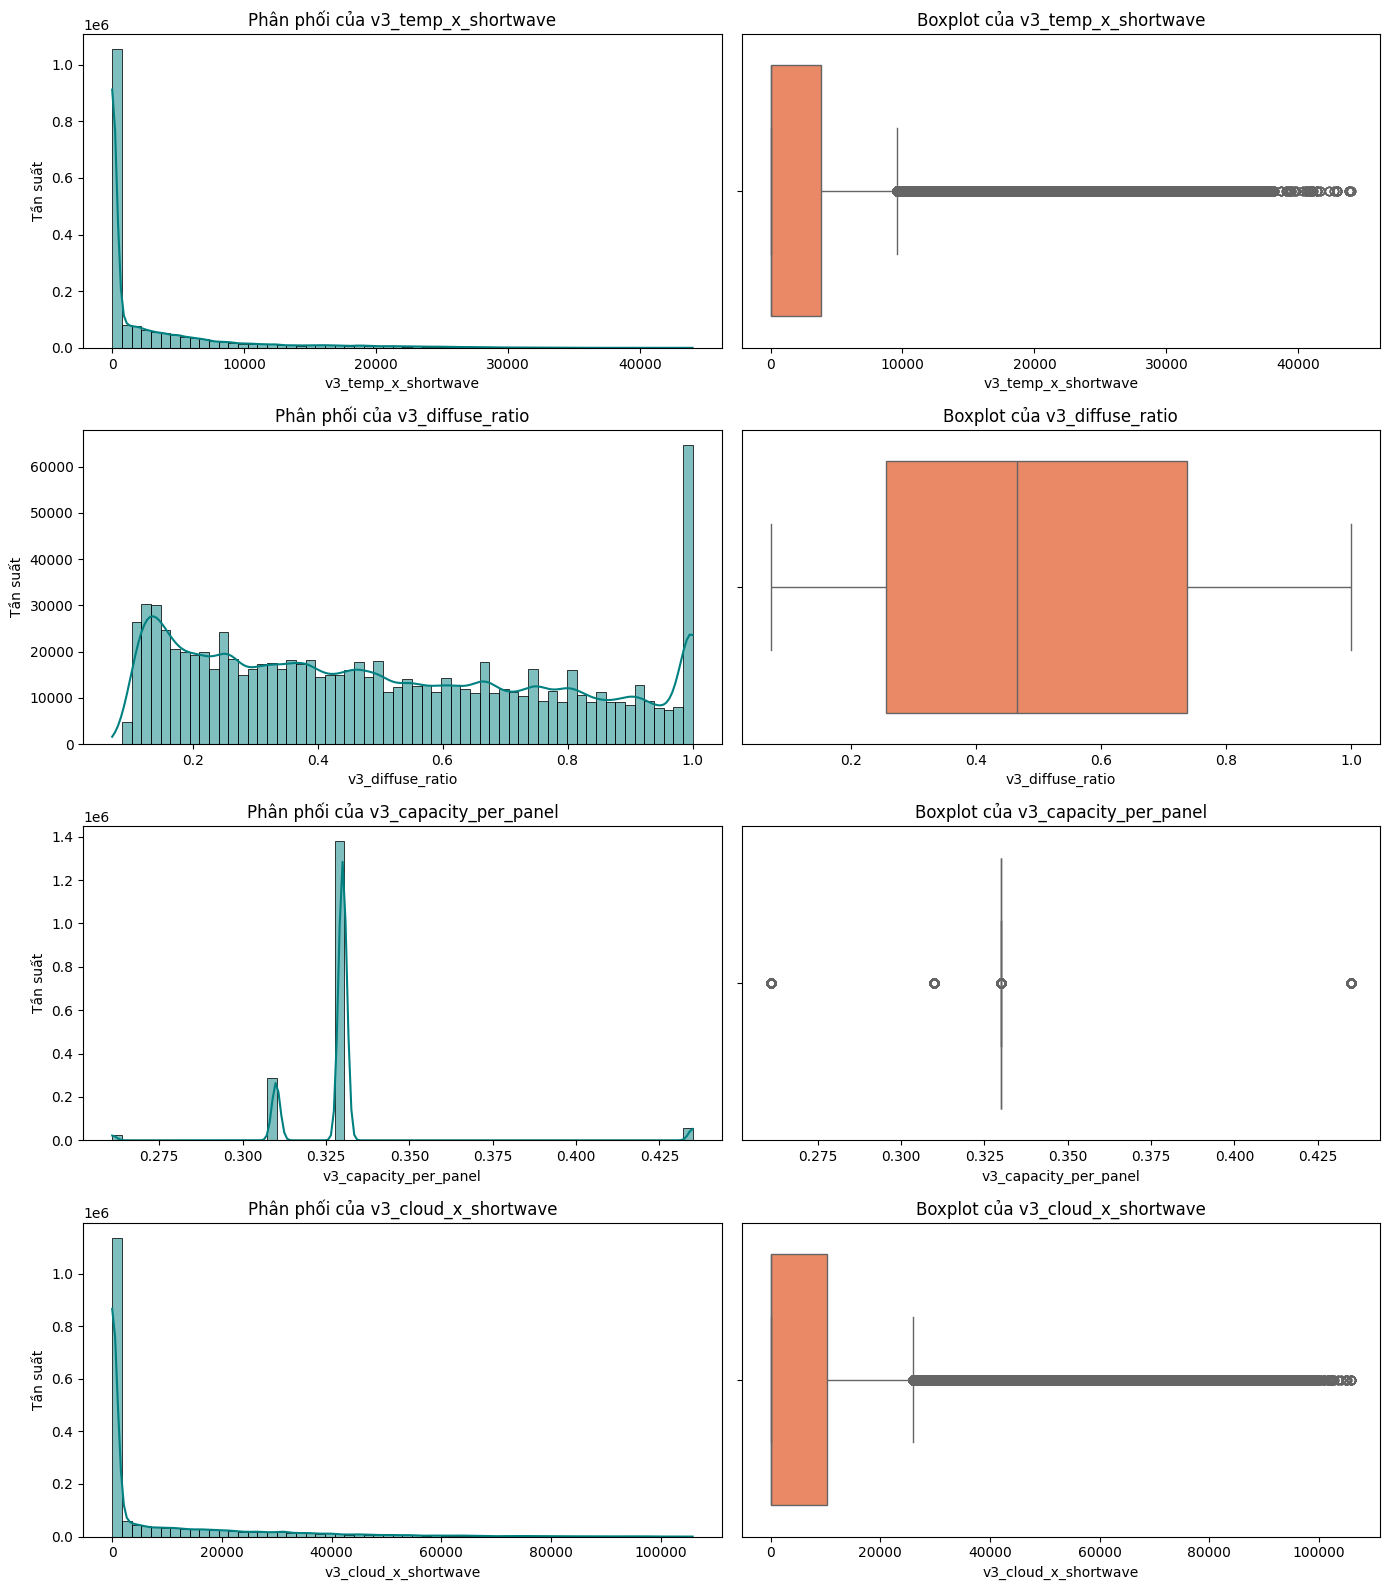

In [37]:
new_features = [f'{VERSION}_temp_x_shortwave', f'{VERSION}_diffuse_ratio', f'{VERSION}_capacity_per_panel', f'{VERSION}_cloud_x_shortwave']
new_features = [f for f in new_features if f in train_features.columns]

# 5.1. Vẽ Histogram và Boxplot (KDE)
fig, axes = plt.subplots(len(new_features), 2, figsize=(14, 4 * len(new_features)))

for i, col in enumerate(new_features):
    # Histogram
    sns.histplot(train_features[col].dropna(), bins=60, kde=True, ax=axes[i, 0], color='teal', edgecolor='black')
    axes[i, 0].set_title(f'Phân phối của {col}')
    axes[i, 0].set_ylabel('Tần suất')
    
    # Boxplot để kiểm tra Outliers cục bộ
    sns.boxplot(x=train_features[col].dropna(), ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot của {col}')

plt.tight_layout()
plt.show()

## 16.4. Đánh giá Tương quan & Đa Cộng tuyến
Kiểm tra xem các features này tương quan tuyến tính (Pearson) và phi tuyến xếp hạng (Spearman) với target ra sao. Đồng thời kiểm tra đa cộng tuyến.

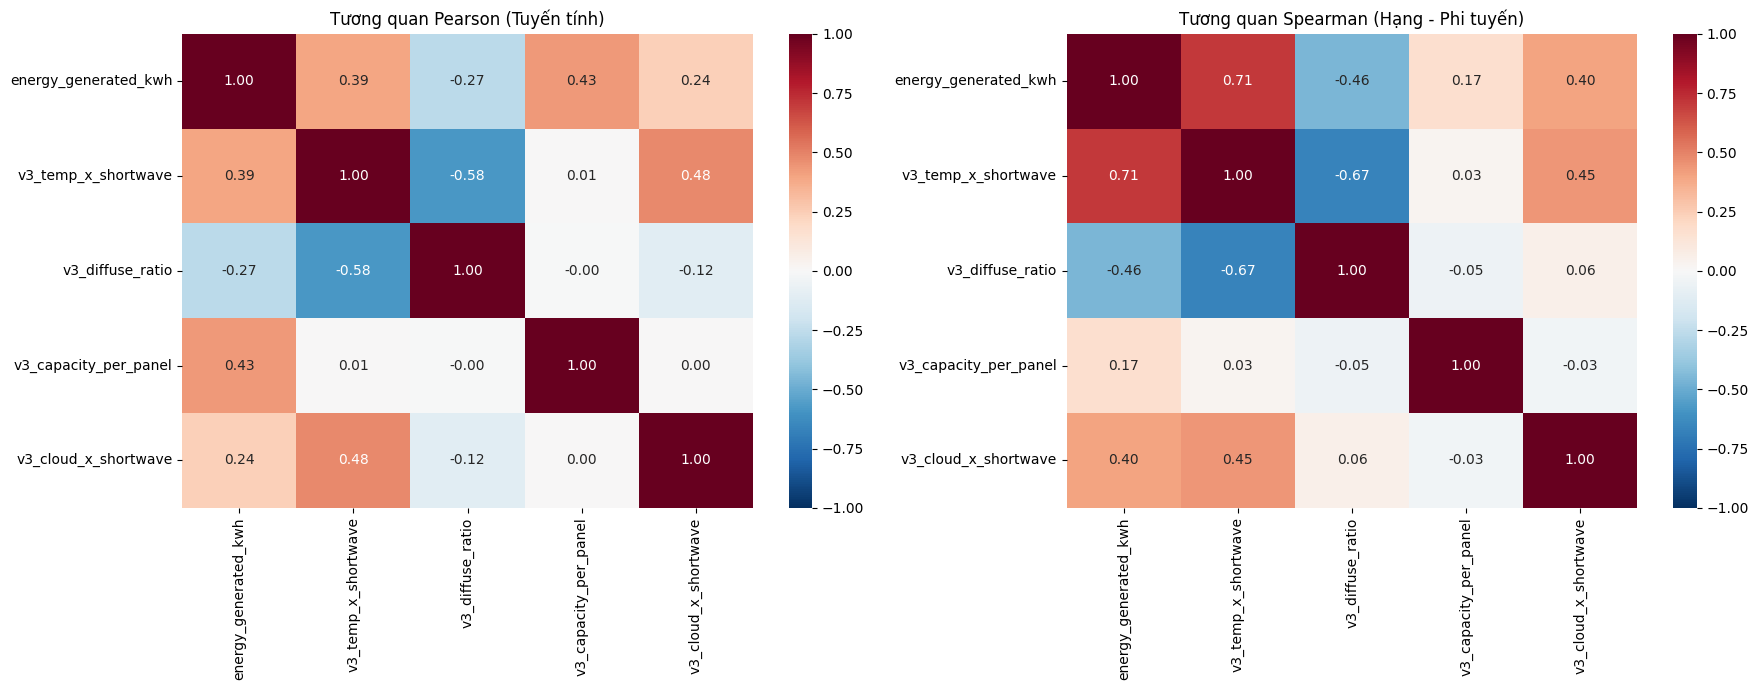

In [38]:
new_features = [f'{VERSION}_temp_x_shortwave', f'{VERSION}_diffuse_ratio', f'{VERSION}_capacity_per_panel', f'{VERSION}_cloud_x_shortwave']
new_features = [f for f in new_features if f in train_features.columns]

corr_cols = ['energy_generated_kwh'] + new_features
df_corr = train_features[corr_cols].dropna()

pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson
sns.heatmap(pearson_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
axes[0].set_title('Tương quan Pearson (Tuyến tính)')

# Spearman
sns.heatmap(spearman_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title('Tương quan Spearman (Hạng - Phi tuyến)')

plt.tight_layout()
plt.show()

### Nhận xét & Đề xuất về Đặc trưng:
- `temp_x_radiation` thường có tương quan cực cao với `energy_generated_kwh`. Điều này là dễ hiểu vì nó chứa đựng thông tin từ bức xạ mặt trời (nguồn sinh năng lượng).
- LƯU Ý MÔ HÌNH HÓA: Đã loại bỏ hoàn toàn các đặc trưng có nguy cơ rò rỉ dữ liệu (Target Leakage) như tỷ lệ khai thác công suất trạm vì nó chứa trực tiếp biến mục tiêu.
- `diffuse_fraction`: Có thể mang hệ số âm với sản lượng (vì ánh sáng khuếch tán thường có cường độ yếu hơn ánh sáng trực tiếp, nên mây mù nhiều sẽ giảm điện).

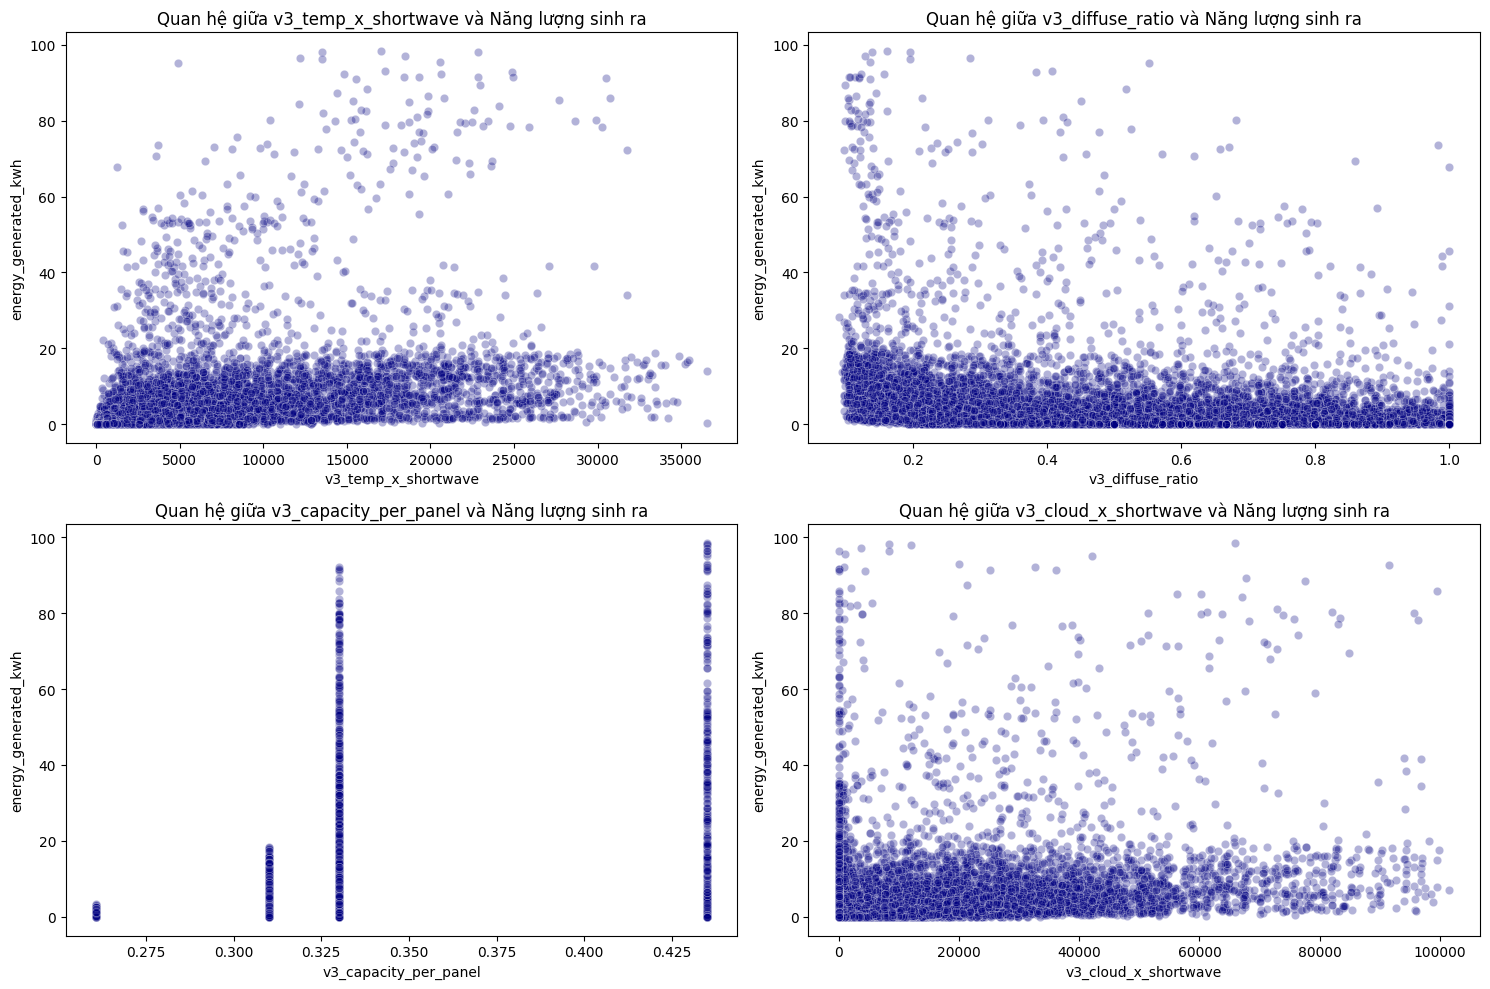

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. FIX TÊN CỘT THÀNH BẢN MỚI
features_to_plot = [
    f'{VERSION}_temp_x_shortwave',
    f'{VERSION}_diffuse_ratio',
    f'{VERSION}_capacity_per_panel',
    f'{VERSION}_cloud_x_shortwave'
]

# Chỉ giữ lại các cột có tồn tại trong data
features_to_plot = [f for f in features_to_plot if f in sample_df.columns]

# 2. VẼ SCATTERPLOT
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    # FIX: Đổi y='energy_generated_kwh' thành TARGET_COL cho chuẩn
    sns.scatterplot(data=sample_df, x=col, y=TARGET_COL, alpha=0.3, ax=axes[i], color='navy')
    axes[i].set_title(f'Quan hệ giữa {col} và Năng lượng sinh ra')

plt.tight_layout()
plt.show()

## 17. Export


In [41]:
paths = {
    'development': f'{OUTPUT_DIR}/{VERSION}_development_features.parquet',
    'test': f'{OUTPUT_DIR}/{VERSION}_test_features.parquet',
    'train_alias': f'{OUTPUT_DIR}/{VERSION}_train_features.parquet',
    'val_alias': f'{OUTPUT_DIR}/{VERSION}_val_features.parquet',
}
# 4 file dac trung chinh da duoc ghi ngay o muc 13 va 14 de giai phong RAM som.

feature_summary = pd.DataFrame(summary_rows)
summary_path = f'{OUTPUT_DIR}/{VERSION}_feature_summary.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)
feature_summary.to_csv(summary_path, index=False)

maps_path = f'{OUTPUT_DIR}/{VERSION}_category_maps.json'
with open(maps_path, 'w', encoding='utf-8') as f:
    json.dump(category_maps, f, ensure_ascii=False, indent=2)

print("--- BANG TONG KET DAC TRUNG ---")
display(feature_summary)
print(f"\nDa luu:")
for k, v in paths.items():
    print(f"- {k:<12}: {v}")
print(f"- summary     : {summary_path}")
print(f"- category_maps: {maps_path}  ({len(category_maps)} bang ma)")
print("Hoan tat Feature Engineering!")


--- BANG TONG KET DAC TRUNG ---


,name,rows,columns,feature_columns,site_count,min_timestamp,max_timestamp,complete_history_rows,incomplete_history_rows,encoded_categorical_columns,unknown_category_rows_total,v3_lag_1_null_rows,v3_lag_4_null_rows,v3_rolling_mean_4_null_rows
0,development,2273970,133,59,42,2020-01-01 00:15:00,2021-12-18 09:15:00,2269938,4032,10,0,42,168,168
1,test_backward_from_development,510468,134,60,42,2021-12-18 09:30:00,2022-04-23 23:45:00,510468,0,10,0,0,0,0
2,train_alias,1791894,134,60,42,2020-01-01 00:15:00,2021-08-20 19:45:00,1787862,4032,10,0,42,168,168
3,val_alias_backward_from_train,482076,134,60,42,2021-08-20 20:00:00,2021-12-18 09:15:00,482076,0,10,0,0,0,0
4,fold_1_train,132523,135,61,13,2020-01-01 00:15:00,2020-04-29 13:45:00,131275,1248,10,0,13,52,52
5,fold_1_val_backward_from_train,289097,135,61,36,2020-04-29 14:00:00,2020-08-27 03:15:00,286889,2208,10,509746,23,92,92
6,fold_2_train,421620,135,61,36,2020-01-01 00:15:00,2020-08-27 03:15:00,418164,3456,10,0,36,144,144
7,fold_2_val_backward_from_train,417729,135,61,39,2020-08-27 03:30:00,2020-12-24 16:45:00,417441,288,10,7535,3,12,12
8,fold_3_train,839349,135,61,39,2020-01-01 00:15:00,2020-12-24 16:45:00,835605,3744,10,0,39,156,156
9,fold_3_val_backward_from_train,470469,135,61,42,2020-12-24 17:00:00,2021-04-23 06:15:00,470181,288,10,22827,3,12,12



Da luu:
- development : ../../data/model/v3/03_features/v3_development_features.parquet
- test        : ../../data/model/v3/03_features/v3_test_features.parquet
- train_alias : ../../data/model/v3/03_features/v3_train_features.parquet
- val_alias   : ../../data/model/v3/03_features/v3_val_features.parquet
- summary     : ../../data/model/v3/03_features/v3_feature_summary.csv
- category_maps: ../../data/model/v3/03_features/v3_category_maps.json  (7 bang ma)
Hoan tat Feature Engineering!
